# **Exercise 1 : (1,2,3)**

In [50]:
import pyomo.environ as pyo
from pyomo.opt import SolverFactory

model = pyo.ConcreteModel()

model.x = pyo.Var(range(5), within=pyo.NonNegativeIntegers)

capacities = [2, 1, 2, 1, 2]

costs = [3, 3, 2, 2, 3]

spaces = [2, 1, 3, 1, 2]

model.obj = pyo.Objective(
    expr=sum(capacities[i] * model.x[i] for i in range(5)),
    sense=pyo.maximize
)

# Constraints
model.budget = pyo.Constraint(expr=sum(costs[i] * model.x[i] for i in range(5)) <= 13)
model.space  = pyo.Constraint(expr=sum(spaces[i] * model.x[i] for i in range(5)) <= 11)

# Solve using CBC
solver = SolverFactory("cbc")
result = solver.solve(model, tee=False)

# Display solution
print("Status:", result.solver.status)
print("Optimal Value:", pyo.value(model.obj))
for i in range(5):
    print(f"x[{i+1}] = {pyo.value(model.x[i])}")


Status: ok
Optimal Value: 9.0
x[1] = 3.0
x[2] = 0.0
x[3] = 1.0
x[4] = 1.0
x[5] = 0.0


# **Exercise 1 : (4,5)**

In [51]:
import pyomo.environ as pyo
from pyomo.opt import SolverFactory

model = pyo.ConcreteModel()

model.x = pyo.Var(range(5), within=pyo.NonNegativeReals)

capacities = [2, 1, 2, 1, 2]

costs = [3, 3, 2, 2, 3]

spaces = [2, 1, 3, 1, 2]

model.obj = pyo.Objective(
    expr=sum(capacities[i] * model.x[i] for i in range(5)),
    sense=pyo.maximize
)

# Constraints
model.budget = pyo.Constraint(expr=sum(costs[i] * model.x[i] for i in range(5)) <= 13)
model.space  = pyo.Constraint(expr=sum(spaces[i] * model.x[i] for i in range(5)) <= 11)

# Solve using CBC
solver = SolverFactory("cbc")
result = solver.solve(model, tee=False)

# Display solution
print("Status:", result.solver.status)
print("Optimal Value:", pyo.value(model.obj))
for i in range(5):
    print(f"x[{i+1}] = {pyo.value(model.x[i])}")


Status: ok
Optimal Value: 9.6
x[1] = 3.4
x[2] = 0.0
x[3] = 1.4
x[4] = 0.0
x[5] = 0.0


# **Exercise 1 : (6)**

In [52]:
import pyomo.environ as pyo
from pyomo.opt import SolverFactory

# Data
capacities = [2, 1, 2, 1, 2]
costs      = [3, 3, 2, 2, 3]
spaces     = [2, 1, 3, 1, 2]

budget  = 13
parking = 11

# ---------- MILP solver ----------
def solve_milp(budget, parking):
    model = pyo.ConcreteModel()
    model.x = pyo.Var(range(5), within=pyo.NonNegativeIntegers)

    model.obj = pyo.Objective(
        expr=sum(capacities[i] * model.x[i] for i in range(5)),
        sense=pyo.maximize
    )

    model.budget = pyo.Constraint(expr=sum(costs[i] * model.x[i] for i in range(5)) <= budget)
    model.space  = pyo.Constraint(expr=sum(spaces[i] * model.x[i] for i in range(5)) <= parking)

    solver = SolverFactory("cbc")
    solver.solve(model, tee=False)

    return pyo.value(model.obj), [pyo.value(model.x[i]) for i in range(5)]


# ---------- LP solver (relaxation) ----------
def solve_lp(budget, parking):
    model = pyo.ConcreteModel()
    model.x = pyo.Var(range(5), within=pyo.NonNegativeReals)

    model.obj = pyo.Objective(
        expr=sum(capacities[i] * model.x[i] for i in range(5)),
        sense=pyo.maximize
    )

    model.budget = pyo.Constraint(expr=sum(costs[i] * model.x[i] for i in range(5)) <= budget)
    model.space  = pyo.Constraint(expr=sum(spaces[i] * model.x[i] for i in range(5)) <= parking)

    solver = SolverFactory("cbc")
    solver.solve(model, tee=False)

    return pyo.value(model.obj), [pyo.value(model.x[i]) for i in range(5)]


# ---------- Run experiments ----------
factor = 1.5

# Original
milp_obj1, milp_sol1 = solve_milp(budget, parking)
lp_obj1, lp_sol1     = solve_lp(budget, parking)

# Scaled
milp_obj2, milp_sol2 = solve_milp(budget*factor, parking*factor)
lp_obj2, lp_sol2     = solve_lp(budget*factor, parking*factor)

# ---------- Print results ----------
print("=== Pyomo Results (CBC) ===")

print("\nOriginal Problem (budget=13, parking=11):")
print("  MILP: Obj =", milp_obj1, "Solution =", milp_sol1)
print("  LP:   Obj =", lp_obj1, "Solution =", lp_sol1)

print("\nScaled Problem (budget=19.5, parking=16.5):")
print("  MILP: Obj =", milp_obj2, "Solution =", milp_sol2)
print("  LP:   Obj =", lp_obj2, "Solution =", lp_sol2)

print("\nObjective changes after scaling by factor 1.5:")
print("  LP:   Δ =", lp_obj2 - lp_obj1, ", Factor =", lp_obj2 / lp_obj1)
print("  MILP: Δ =", milp_obj2 - milp_obj1, ", Factor =", milp_obj2 / milp_obj1)


=== Pyomo Results (CBC) ===

Original Problem (budget=13, parking=11):
  MILP: Obj = 9.0 Solution = [3.0, 0.0, 1.0, 1.0, 0.0]
  LP:   Obj = 9.6 Solution = [3.4, 0.0, 1.4, 0.0, 0.0]

Scaled Problem (budget=19.5, parking=16.5):
  MILP: Obj = 14.0 Solution = [5.0, 0.0, 2.0, 0.0, 0.0]
  LP:   Obj = 14.399999999999999 Solution = [5.1, 0.0, 2.1, 0.0, 0.0]

Objective changes after scaling by factor 1.5:
  LP:   Δ = 4.799999999999999 , Factor = 1.5
  MILP: Δ = 5.0 , Factor = 1.5555555555555556


# **Exercise 1 : (7)**

Scale     LP Objective   MILP Objective 
1         9.60           9.00           
2         19.20          19.00          
3         28.80          28.00          
4         38.40          38.00          


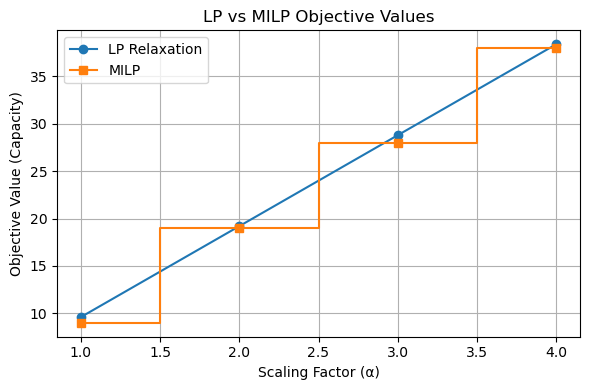

In [53]:
import pyomo.environ as pyo
import matplotlib.pyplot as plt

# Data
capacity = [2, 1, 2, 1, 2]   # objective coefficients
cost     = [3, 3, 2, 2, 3]   # budget coefficients
space    = [2, 1, 3, 1, 2]   # parking coefficients

budget_RHS = 13
space_RHS = 11
scales = [1, 2, 3, 4]

def solve_model(integer=True):
    """Return dict {scale: optimal_obj} for given integer/binary setting"""
    results = {}
    for alpha in scales:
        model = pyo.ConcreteModel()

        n = len(capacity)
        model.x = pyo.Var(range(n), domain=pyo.NonNegativeIntegers if integer else pyo.NonNegativeReals)

        # Objective: maximize total capacity
        model.obj = pyo.Objective(expr=sum(capacity[i]*model.x[i] for i in range(n)), sense=pyo.maximize)

        # Constraints
        model.budget = pyo.Constraint(expr=sum(cost[i]*model.x[i] for i in range(n)) <= budget_RHS*alpha)
        model.space  = pyo.Constraint(expr=sum(space[i]*model.x[i] for i in range(n)) <= space_RHS*alpha)

        solver = pyo.SolverFactory("glpk")
        solver.solve(model, tee=False)

        results[alpha] = pyo.value(model.obj)

    return results

# Solve LP and MILP
lp_results   = solve_model(integer=False)
milp_results = solve_model(integer=True)

# Print results
print(f"{'Scale':<10}{'LP Objective':<15}{'MILP Objective':<15}")
for alpha in scales:
    print(f"{alpha:<10}{lp_results[alpha]:<15.2f}{milp_results[alpha]:<15.2f}")

# Plot
plt.figure(figsize=(6,4))
plt.plot(scales, [lp_results[a] for a in scales], marker='o', label="LP Relaxation")
plt.step(scales, [milp_results[a] for a in scales], where='mid', marker='s', label="MILP")

plt.xlabel("Scaling Factor (α)")
plt.ylabel("Objective Value (Capacity)")
plt.title("LP vs MILP Objective Values")
plt.legend()
plt.tight_layout()
plt.grid(True)
plt.show()

# **Exercise 2 : (1,2,3)**

In [59]:
import pyomo.environ as pyo
import csv

# --- Load data ---
b, c, A = [], [], []
with open("/home/banibrata/Desktop/lp_ip.csv", "r") as file:  # use full path if needed
    reader = csv.reader(file)
    b = [float(val) for val in next(reader)]            # RHS (5 values)
    c = [float(val) for val in next(reader)]            # Objective (500 values)
    for i in range(5):                                  # Constraint matrix
        A.append([float(val) for val in next(reader)])

# --- Model Setup ---
n, m = 500, 5
model = pyo.ConcreteModel()
model.J = pyo.RangeSet(1, n)
model.I = pyo.RangeSet(1, m)

model.c = pyo.Param(model.J, initialize=lambda m,j: c[j-1])
model.b = pyo.Param(model.I, initialize=lambda m,i: b[i-1])
model.a = pyo.Param(model.I, model.J, initialize=lambda m,i,j: A[i-1][j-1])

# Toggle MILP vs LP
use_milp = True  # set False for LP relaxation
if use_milp:
    model.x = pyo.Var(model.J, domain=pyo.Binary)
else:
    model.x = pyo.Var(model.J, domain=pyo.NonNegativeReals, bounds=(0,1))

# Objective
model.obj = pyo.Objective(expr=sum(model.c[j]*model.x[j] for j in model.J),
                          sense=pyo.maximize)

# Constraints
def constr_rule(m, i):
    return sum(m.a[i,j]*m.x[j] for j in m.J) <= m.b[i]
model.constr = pyo.Constraint(model.I, rule=constr_rule)

# --- Solve with CBC ---
solver = pyo.SolverFactory("cbc")
results = solver.solve(model, tee=True) 

# --- Results ---
print("\n--- Results ---")
print(f"Solver status: {results.solver.status}")
print(f"Termination condition: {results.solver.termination_condition}")
print(f"Objective Value: {pyo.value(model.obj):.2f}")
print(f"Solve time: {results.solver.time:.4f} seconds")


Welcome to the CBC MILP Solver 
Version: 2.10.11 
Build Date: Jan 21 2024 

command line - /usr/bin/cbc -printingOptions all -import /tmp/tmptj5bj94n.pyomo.lp -stat=1 -solve -solu /tmp/tmptj5bj94n.pyomo.soln (default strategy 1)
Option for printingOptions changed from normal to all
 CoinLpIO::readLp(): Maximization problem reformulated as minimization
Coin0009I Switching back to maximization to get correct duals etc
Presolve 5 (0) rows, 500 (0) columns and 2500 (0) elements
Statistics for presolved model
Original problem has 500 integers (500 of which binary)
==== 0 zero objective 372 different
==== absolute objective values 372 different
==== for integers 0 zero objective 372 different
==== for integers absolute objective values 372 different
===== end objective counts


Problem has 5 rows, 500 columns (500 with objective) and 2500 elements
Column breakdown:
0 of type 0.0->inf, 0 of type 0.0->up, 0 of type lo->inf, 
0 of type lo->up, 0 of type free, 0 of type fixed, 
0 of type -inf->0

# **Exercise 2 : (4,5)**

In [60]:
import pyomo.environ as pyo
import csv

# --- Load data ---
b, c, A = [], [], []
with open("/home/banibrata/Desktop/lp_ip.csv", "r") as file:  # use full path if needed
    reader = csv.reader(file)
    b = [float(val) for val in next(reader)]            # RHS (5 values)
    c = [float(val) for val in next(reader)]            # Objective (500 values)
    for i in range(5):                                  # Constraint matrix
        A.append([float(val) for val in next(reader)])

# --- Model Setup ---
n, m = 500, 5
model = pyo.ConcreteModel()
model.J = pyo.RangeSet(1, n)
model.I = pyo.RangeSet(1, m)

model.c = pyo.Param(model.J, initialize=lambda m,j: c[j-1])
model.b = pyo.Param(model.I, initialize=lambda m,i: b[i-1])
model.a = pyo.Param(model.I, model.J, initialize=lambda m,i,j: A[i-1][j-1])

# Toggle MILP vs LP
use_milp = False  # set False for LP relaxation
if use_milp:
    model.x = pyo.Var(model.J, domain=pyo.Binary)
else:
    model.x = pyo.Var(model.J, domain=pyo.NonNegativeReals, bounds=(0,1))

# Objective
model.obj = pyo.Objective(expr=sum(model.c[j]*model.x[j] for j in model.J),
                          sense=pyo.maximize)

# Constraints
def constr_rule(m, i):
    return sum(m.a[i,j]*m.x[j] for j in m.J) <= m.b[i]
model.constr = pyo.Constraint(model.I, rule=constr_rule)

# --- Solve with CBC ---
solver = pyo.SolverFactory("cbc")
results = solver.solve(model, tee=True)  

# --- Results ---
print("\n--- Results ---")
print(f"Solver status: {results.solver.status}")
print(f"Termination condition: {results.solver.termination_condition}")
print(f"Objective Value: {pyo.value(model.obj):.2f}")
print(f"Solve time: {results.solver.time:.4f} seconds")


Welcome to the CBC MILP Solver 
Version: 2.10.11 
Build Date: Jan 21 2024 

command line - /usr/bin/cbc -printingOptions all -import /tmp/tmpogevw3yi.pyomo.lp -stat=1 -solve -solu /tmp/tmpogevw3yi.pyomo.soln (default strategy 1)
Option for printingOptions changed from normal to all
 CoinLpIO::readLp(): Maximization problem reformulated as minimization
Coin0009I Switching back to maximization to get correct duals etc
Presolve 5 (0) rows, 500 (0) columns and 2500 (0) elements
Statistics for presolved model


Problem has 5 rows, 500 columns (500 with objective) and 2500 elements
Column breakdown:
0 of type 0.0->inf, 0 of type 0.0->up, 0 of type lo->inf, 
0 of type lo->up, 0 of type free, 0 of type fixed, 
0 of type -inf->0.0, 0 of type -inf->up, 500 of type 0.0->1.0 
Row breakdown:
0 of type E 0.0, 0 of type E 1.0, 0 of type E -1.0, 
0 of type E other, 0 of type G 0.0, 0 of type G 1.0, 
0 of type G other, 0 of type L 0.0, 0 of type L 1.0, 
5 of type L other, 0 of type Range 0.0->1.0, 0 of

# **Exercise 3 : (1,2,3,4)**

In [56]:
import pyomo.environ as pyo
import shutil, time

# --- Data from table ---
months = list(range(1, 13))
prod_cost = {1:250,  2:300,  3:700,  4:500,  5:450,  6:90,
             7:200,  8:400,  9:200, 10:250, 11:350, 12:150}
demand    = {1:1000, 2:2000, 3:5000, 4:4000, 5:3000, 6:500,
             7:1000, 8:8000, 9:4000,10:2000,11:6000,12:3000}

storage_cost = 30
capacity = 10000   # monthly production limit

# --- Model ---
model = pyo.ConcreteModel()
model.T = pyo.Set(initialize=months)

# Decision variables
model.x = pyo.Var(model.T, domain=pyo.NonNegativeReals)  # production
model.I = pyo.Var(model.T, domain=pyo.NonNegativeReals)  # inventory

# Objective: variable production cost + storage
model.obj = pyo.Objective(
    expr=sum(prod_cost[t]*model.x[t] + storage_cost*model.I[t] for t in model.T),
    sense=pyo.minimize
)

# Inventory balance
def inv_rule(m, t):
    if t == 1:
        return m.x[1] == demand[1] + m.I[1]   # I0 = 0
    else:
        return m.I[t-1] + m.x[t] == demand[t] + m.I[t]
model.inv_constr = pyo.Constraint(model.T, rule=inv_rule)

# End inventory must be 0
model.end_inventory = pyo.Constraint(expr = model.I[12] == 0)

# Capacity limit
def cap_rule(m, t):
    return m.x[t] <= capacity
model.capacity = pyo.Constraint(model.T, rule=cap_rule)

# --- Solver selection ---
if shutil.which("cbc"):
    solver = pyo.SolverFactory("cbc")
elif shutil.which("glpsol"):
    solver = pyo.SolverFactory("glpk")
else:
    raise RuntimeError("No CBC or GLPK solver found.")

# --- Solve ---
start = time.time()
results = solver.solve(model, tee=False)
elapsed = time.time() - start

# --- Results ---
print(f"Solver status: {results.solver.status}")
print(f"Termination condition: {results.solver.termination_condition}")
print(f"Objective (total cost): {pyo.value(model.obj):,.2f}")
print(f"Solve time: {elapsed:.4f} seconds\n")

print("Month | Produce | Inventory_end")
print("-"*32)
for t in months:
    print(f"{t:5d} | {model.x[t].value:7.0f} | {model.I[t].value:13.0f}")


Solver status: ok
Termination condition: optimal
Objective (total cost): 9,585,000.00
Solve time: 0.0382 seconds

Month | Produce | Inventory_end
--------------------------------
    1 |   10000 |          9000
    2 |    5000 |         12000
    3 |       0 |          7000
    4 |       0 |          3000
    5 |       0 |             0
    6 |   10000 |          9500
    7 |       0 |          8500
    8 |       0 |           500
    9 |   10000 |          6500
   10 |    1500 |          6000
   11 |       0 |             0
   12 |    3000 |             0


# **Exercise 3 : (5)**

In [57]:
import pyomo.environ as pyo

# --- 1. Data Definition ---
# Given parameters for the problem
F = 200000  # Fixed cost
H = 30      # Holding cost per unit per month
M = 10000   # Max production capacity

# Monthly data (using a dictionary for clarity)
# Demands for months 1 through 12
demands = {
    1: 1000, 2: 2000, 3: 5000, 4: 4000, 5: 3000, 6: 500,
    7: 1000, 8: 8000, 9: 4000, 10: 2000, 11: 6000, 12: 3000
}

# Variable costs for months 1 through 12
var_costs = {
    1: 250, 2: 300, 3: 700, 4: 500, 5: 450, 6: 90,
    7: 200, 8: 400, 9: 200, 10: 250, 11: 350, 12: 150
}

# --- 2. Pyomo Model ---
# Create a concrete model instance
model = pyo.ConcreteModel(name="Bindu_Steel_Works")

# Define sets for the model
model.T = pyo.RangeSet(1, 12)       # Set for months
model.T_inv = pyo.RangeSet(0, 12)   # Set for inventory time points

# Load data into model parameters
model.D = pyo.Param(model.T, initialize=demands)
model.C = pyo.Param(model.T, initialize=var_costs)

# --- 3. Decision Variables ---
# Production quantity in each month
model.P = pyo.Var(model.T, domain=pyo.NonNegativeReals)
# Inventory at the end of each month
model.I = pyo.Var(model.T_inv, domain=pyo.NonNegativeReals)
# Binary variable: 1 if production occurs in a month, 0 otherwise
model.Y = pyo.Var(model.T, domain=pyo.Binary)

# --- 4. Objective Function ---
# Minimize the total annual cost
def total_cost_rule(m):
    fixed_cost = sum(F * m.Y[t] for t in m.T)
    variable_cost = sum(m.C[t] * m.P[t] for t in m.T)
    holding_cost = sum(H * m.I[t] for t in m.T)
    return fixed_cost + variable_cost + holding_cost

model.total_cost = pyo.Objective(rule=total_cost_rule, sense=pyo.minimize)

# --- 5. Constraints ---
# Inventory balance constraint for each month
def inventory_balance_rule(m, t):
    return m.I[t] == m.I[t-1] + m.P[t] - m.D[t]

model.inventory_balance = pyo.Constraint(model.T, rule=inventory_balance_rule)

# Link production quantity to the binary production decision (Big-M)
def production_capacity_rule(m, t):
    return m.P[t] <= M * m.Y[t]

model.production_capacity = pyo.Constraint(model.T, rule=production_capacity_rule)

# Boundary conditions for inventory
model.initial_inventory = pyo.Constraint(expr=model.I[0] == 0)
model.final_inventory = pyo.Constraint(expr=model.I[12] == 0)

# --- 6. Solve the Model ---
# Create a solver instance and solve the model
solver = pyo.SolverFactory('glpk') # You can also use 'cbc', 'gurobi', etc.
results = solver.solve(model, tee=False) # Set tee=True to see solver output

# --- 7. Display Results ---
print("--- Bindu Steel Works Optimal Plan ---")
print(f"Solver Status: {results.solver.status}")
print(f"Minimum Total Annual Cost = ₹{pyo.value(model.total_cost):,.2f}\n")

print(f"{'Month':<6} | {'Demand':>8} | {'Prod. Qty':>10} | {'End Inv.':>10} | {'Produce? (Y)':>12}")
print("-" * 65)
for t in model.T:
    demand_val = model.D[t]
    prod_val = pyo.value(model.P[t])
    inv_val = pyo.value(model.I[t])
    y_val = "Yes" if pyo.value(model.Y[t]) > 0.5 else "No"
    print(f"{t:<6} | {demand_val:8,.0f} | {prod_val:10,.0f} | {inv_val:10,.0f} | {y_val:>12}")

--- Bindu Steel Works Optimal Plan ---
Solver Status: ok
Minimum Total Annual Cost = ₹10,785,000.00

Month  |   Demand |  Prod. Qty |   End Inv. | Produce? (Y)
-----------------------------------------------------------------
1      |    1,000 |     10,000 |      9,000 |          Yes
2      |    2,000 |      5,000 |     12,000 |          Yes
3      |    5,000 |          0 |      7,000 |           No
4      |    4,000 |          0 |      3,000 |           No
5      |    3,000 |          0 |          0 |           No
6      |      500 |     10,000 |      9,500 |          Yes
7      |    1,000 |          0 |      8,500 |           No
8      |    8,000 |          0 |        500 |           No
9      |    4,000 |     10,000 |      6,500 |          Yes
10     |    2,000 |      1,500 |      6,000 |          Yes
11     |    6,000 |          0 |          0 |           No
12     |    3,000 |      3,000 |          0 |          Yes


# **Exercise 3 : (6)**

In [58]:
import pyomo.environ as pyo

# --- 1. Data Definition ---
# Given parameters for the problem
F = 400000  # Fixed cost
H = 30      # Holding cost per unit per month
M = 10000   # Max production capacity

# Monthly data (using a dictionary for clarity)
# Demands for months 1 through 12
demands = {
    1: 1000, 2: 2000, 3: 5000, 4: 4000, 5: 3000, 6: 500,
    7: 1000, 8: 8000, 9: 4000, 10: 2000, 11: 6000, 12: 3000
}

# Variable costs for months 1 through 12
var_costs = {
    1: 250, 2: 300, 3: 700, 4: 500, 5: 450, 6: 90,
    7: 200, 8: 400, 9: 200, 10: 250, 11: 350, 12: 150
}

# --- 2. Pyomo Model ---
# Create a concrete model instance
model = pyo.ConcreteModel(name="Bindu_Steel_Works")

# Define sets for the model
model.T = pyo.RangeSet(1, 12)       # Set for months
model.T_inv = pyo.RangeSet(0, 12)   # Set for inventory time points

# Load data into model parameters
model.D = pyo.Param(model.T, initialize=demands)
model.C = pyo.Param(model.T, initialize=var_costs)

# --- 3. Decision Variables ---
# Production quantity in each month
model.P = pyo.Var(model.T, domain=pyo.NonNegativeReals)
# Inventory at the end of each month
model.I = pyo.Var(model.T_inv, domain=pyo.NonNegativeReals)
# Binary variable: 1 if production occurs in a month, 0 otherwise
model.Y = pyo.Var(model.T, domain=pyo.Binary)

# --- 4. Objective Function ---
# Minimize the total annual cost
def total_cost_rule(m):
    fixed_cost = sum(F * m.Y[t] for t in m.T)
    variable_cost = sum(m.C[t] * m.P[t] for t in m.T)
    holding_cost = sum(H * m.I[t] for t in m.T)
    return fixed_cost + variable_cost + holding_cost

model.total_cost = pyo.Objective(rule=total_cost_rule, sense=pyo.minimize)

# --- 5. Constraints ---
# Inventory balance constraint for each month
def inventory_balance_rule(m, t):
    return m.I[t] == m.I[t-1] + m.P[t] - m.D[t]

model.inventory_balance = pyo.Constraint(model.T, rule=inventory_balance_rule)

# Link production quantity to the binary production decision (Big-M)
def production_capacity_rule(m, t):
    return m.P[t] <= M * m.Y[t]

model.production_capacity = pyo.Constraint(model.T, rule=production_capacity_rule)

# Boundary conditions for inventory
model.initial_inventory = pyo.Constraint(expr=model.I[0] == 0)
model.final_inventory = pyo.Constraint(expr=model.I[12] == 0)

# --- 6. Solve the Model ---
# Create a solver instance and solve the model
solver = pyo.SolverFactory('glpk') # You can also use 'cbc', 'gurobi', etc.
results = solver.solve(model, tee=False) # Set tee=True to see solver output

# --- 7. Display Results ---
print("--- Bindu Steel Works Optimal Plan ---")
print(f"Solver Status: {results.solver.status}")
print(f"Minimum Total Annual Cost = ₹{pyo.value(model.total_cost):,.2f}\n")

print(f"{'Month':<6} | {'Demand':>8} | {'Prod. Qty':>10} | {'End Inv.':>10} | {'Produce? (Y)':>12}")
print("-" * 65)
for t in model.T:
    demand_val = model.D[t]
    prod_val = pyo.value(model.P[t])
    inv_val = pyo.value(model.I[t])
    y_val = "Yes" if pyo.value(model.Y[t]) > 0.5 else "No"
    print(f"{t:<6} | {demand_val:8,.0f} | {prod_val:10,.0f} | {inv_val:10,.0f} | {y_val:>12}")

--- Bindu Steel Works Optimal Plan ---
Solver Status: ok
Minimum Total Annual Cost = ₹11,985,000.00

Month  |   Demand |  Prod. Qty |   End Inv. | Produce? (Y)
-----------------------------------------------------------------
1      |    1,000 |     10,000 |      9,000 |          Yes
2      |    2,000 |      5,000 |     12,000 |          Yes
3      |    5,000 |          0 |      7,000 |           No
4      |    4,000 |          0 |      3,000 |           No
5      |    3,000 |          0 |          0 |           No
6      |      500 |     10,000 |      9,500 |          Yes
7      |    1,000 |          0 |      8,500 |           No
8      |    8,000 |          0 |        500 |           No
9      |    4,000 |     10,000 |      6,500 |          Yes
10     |    2,000 |      1,500 |      6,000 |          Yes
11     |    6,000 |          0 |          0 |           No
12     |    3,000 |      3,000 |          0 |          Yes
